` Self-Attention on Product Reviews`

## Project Overview

This project implements a self-attention mechanism
on an e-commerce product reviews dataset.

## Objectives

- Tokenize product reviews
- Build a vocabulary
- Convert words to token IDs
- Apply an Embedding layer
- Calculate Q, K, and V
- Calculate QK^T
- Apply scaling and Softmax
- Calculate Attention × V
- Visualize attention weights using a heatmap
- Identify words receiving the highest attention

## Self-Attention Formula

Attention(Q,K,V) =
Softmax(QK^T / sqrt(d_k)) V

## Technologies

- Python
- TensorFlow
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense

In [3]:
# Load dataset
df = pd.read_csv('/content/product_reviews_1000.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 5)


,Review Text,Sentiment Label,Window,User Name,User ID
0,"Great value for money, I am very satisfied!",Positive,Flipkart,Arjun Patel,U0001
1,Poor quality and very disappointing service.,Negative,Flipkart,Priya Verma,U0002
2,"The product quality is outstanding, and delive...",Positive,Amazon,Arjun Yadav,U0003
3,"Terrible build quality, broke within two days ...",Negative,Amazon,Kiran Mehta,U0004
4,"Terrible build quality, broke within two days ...",Negative,Flipkart,Sneha Singh,U0005


In [5]:
# Display dataset information
print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.tail())

Columns:
['Review Text', 'Sentiment Label', 'Window', 'User Name', 'User ID']

Dataset shape:
(1000, 5)

Missing values:
Review Text        0
Sentiment Label    0
Window             0
User Name          0
User ID            0
dtype: int64

First 5 rows:


,Review Text,Sentiment Label,Window,User Name,User ID
995,"Great value for money, I am very satisfied!",Positive,Flipkart,Rohit Kapoor,U0996
996,"Meets basic expectations, but could be improved.",Neutral,Flipkart,Kiran Bose,U0997
997,"It's decent, but I've seen better at this price.",Neutral,Amazon,Amit Bose,U0998
998,"Stopped working after a week, not worth the pr...",Negative,Amazon,Sneha Bose,U0999
999,"Great value for money, I am very satisfied!",Positive,Flipkart,Kiran Yadav,U1000


In [6]:
# Possible names for the review/text column
possible_text_columns = [
    "review",
    "Review",
    "reviews",
    "Reviews",
    "text",
    "Text",
    "review_text",
    "Review Text"
]

TEXT_COLUMN = None

for column in possible_text_columns:
    if column in df.columns:
        TEXT_COLUMN = column
        break

if TEXT_COLUMN is None:
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError("Please set TEXT_COLUMN manually.")

print("Text column:", TEXT_COLUMN)

Text column: Review Text


In [7]:
# Remove missing reviews
df = df.dropna(subset=[TEXT_COLUMN]).copy()

# Convert reviews to strings
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)

print("Number of reviews:", len(df))

Number of reviews: 1000


In [8]:
# Create tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Build vocabulary
tokenizer.fit_on_texts(df[TEXT_COLUMN])

# Get vocabulary
word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

print("\nFirst 20 words:")
for word, index in list(word_index.items())[:20]:
    print(word, "->", index)

Vocabulary size: 88

First 20 words:
<OOV> -> 1
and -> 2
the -> 3
but -> 4
performance -> 5
very -> 6
product -> 7
quality -> 8
not -> 9
money -> 10
design -> 11
of -> 12
this -> 13
nothing -> 14
i -> 15
worth -> 16
is -> 17
price -> 18
better -> 19
works -> 20


In [9]:
# Convert reviews into sequences of token IDs
sequences = tokenizer.texts_to_sequences(df[TEXT_COLUMN])

# Display examples
for i in range(min(5, len(sequences))):
    print("Review:")
    print(df[TEXT_COLUMN].iloc[i])

    print("Token IDs:")
    print(sequences[i])

    print("-" * 50)

Review:
Great value for money, I am very satisfied!
Token IDs:
[21, 22, 23, 10, 15, 24, 6, 25]
--------------------------------------------------
Review:
Poor quality and very disappointing service.
Token IDs:
[42, 8, 2, 6, 43, 44]
--------------------------------------------------
Review:
The product quality is outstanding, and delivery was super fast!
Token IDs:
[3, 7, 8, 17, 51, 2, 52, 53, 54, 55]
--------------------------------------------------
Review:
Terrible build quality, broke within two days of use.
Token IDs:
[59, 60, 8, 61, 62, 63, 64, 12, 65]
--------------------------------------------------
Review:
Terrible build quality, broke within two days of use.
Token IDs:
[59, 60, 8, 61, 62, 63, 64, 12, 65]
--------------------------------------------------


In [10]:
# Find maximum sequence length
max_length = max(len(sequence) for sequence in sequences)

print("Maximum sequence length:", max_length)

# Pad sequences
X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("Padded data shape:", X.shape)

Maximum sequence length: 10
Padded data shape: (1000, 10)


In [11]:
# Vocabulary size
vocab_size = len(word_index) + 1

# Embedding dimension
embedding_dim = 64

# Create embedding layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)

# Apply embedding
embeddings = embedding_layer(X)

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Embedding shape:", embeddings.shape)

Vocabulary size: 89
Embedding dimension: 64
Embedding shape: (1000, 10, 64)


In [12]:
# Select one review
sentence_index = 0

selected_sentence = df[TEXT_COLUMN].iloc[sentence_index]

print("Selected sentence:")
print(selected_sentence)

Selected sentence:
Great value for money, I am very satisfied!


In [13]:
# Convert selected sentence to token IDs
selected_sequence = tokenizer.texts_to_sequences(
    [selected_sentence]
)[0]

# Create reverse vocabulary
index_word = {
    index: word
    for word, index in word_index.items()
}

# Convert token IDs back to words
tokens = [
    index_word[token]
    for token in selected_sequence
]

print("Tokens:")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Tokens:
['great', 'value', 'for', 'money', 'i', 'am', 'very', 'satisfied']

Number of tokens: 8


In [14]:
# Get embeddings for the selected sentence
sentence_embedding = embedding_layer(
    tf.constant([selected_sequence])
)

# Remove batch dimension
sentence_embedding = sentence_embedding[0]

print("Sentence embedding shape:")
print(sentence_embedding.shape)

Sentence embedding shape:
(8, 64)


In [15]:
# Dimension of Query and Key
d_k = embedding_dim

# Create trainable projection layers
W_Q = Dense(d_k, use_bias=False)
W_K = Dense(d_k, use_bias=False)
W_V = Dense(d_k, use_bias=False)

# Calculate Q, K, V
Q = W_Q(sentence_embedding)
K = W_K(sentence_embedding)
V = W_V(sentence_embedding)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (8, 64)
K shape: (8, 64)
V shape: (8, 64)


In [16]:
# Calculate QK^T
scores = tf.matmul(
    Q,
    K,
    transpose_b=True
)

print("QK^T shape:")
print(scores.shape)

QK^T shape:
(8, 8)


In [28]:
# Scale attention scores
scaled_scores = scores / tf.sqrt(
    tf.cast(d_k, tf.float32)
)

print("Scaled scores:")
print(scaled_scores)
print(d_k)

Scaled scores:
tf.Tensor(
[[ 2.19897646e-03 -5.49918972e-04  6.23702581e-05 -9.38432873e-04
   6.41577062e-05  7.90325052e-04  8.92518554e-04 -3.93924682e-04]
 [-1.13315543e-03  1.72083324e-04  6.24870765e-04  1.66860118e-04
   7.38806266e-04  7.36312359e-04  1.21365930e-03 -1.09637855e-04]
 [-1.31956331e-04  4.47328435e-04 -9.66098858e-04 -3.28978349e-04
   6.81001344e-04  1.15956645e-03 -1.26134534e-03 -7.94602325e-04]
 [-1.08520733e-03  1.98995112e-05  5.79467334e-04  3.28665010e-05
   1.16254378e-03 -4.10767214e-04  2.52137193e-04  1.59959716e-04]
 [ 3.29305010e-04  1.67182297e-05 -4.88868682e-06  1.55727495e-04
  -1.09493616e-03  1.16523192e-03  2.88532116e-04  3.65240674e-04]
 [-6.50235801e-04  6.40292419e-04  1.43304258e-03 -1.53585628e-04
  -6.45856373e-04 -5.43413684e-04 -8.38290667e-04 -1.96000619e-04]
 [ 4.87019497e-05 -6.24461216e-04 -1.93136535e-03  3.29701812e-04
   5.23563242e-04 -9.76912328e-04 -1.10791635e-03 -1.23899372e-06]
 [-5.85912378e-04 -3.29182600e-04 -6.298993

In [18]:
# Apply softmax to get attention weights
attention_weights = tf.nn.softmax(
    scaled_scores,
    axis=-1
)

print("Attention weights:")
print(attention_weights)

Attention weights:
tf.Tensor(
[[0.12524183 0.12489802 0.12497453 0.12484951 0.12497475 0.12506554
  0.1250783  0.12491751]
 [0.12482079 0.12498382 0.12504043 0.12498317 0.12505467 0.12505436
  0.12511407 0.12494862]
 [0.12500213 0.12507457 0.1248979  0.1249775  0.12510379 0.12516367
  0.12486103 0.12491932]
 [0.12485329 0.12499134 0.1250613  0.12499297 0.12513424 0.12493753
  0.12502037 0.12500884]
 [0.12502205 0.12498298 0.12498029 0.12500036 0.12484413 0.12512662
  0.12501696 0.12502655]
 [0.12493362 0.12509495 0.12519416 0.12499569 0.12493417 0.12494697
  0.12491012 0.12499038]
 [0.1250645  0.12498034 0.12481711 0.12509964 0.1251239  0.1249363
  0.12491993 0.12505825]
 [0.12494721 0.12497929 0.12494171 0.12502214 0.12493582 0.12509453
  0.12510152 0.12497783]], shape=(8, 8), dtype=float32)


In [19]:
# Convert to NumPy
attention_np = attention_weights.numpy()

# Check row sums
row_sums = attention_np.sum(axis=1)

print("Attention row sums:")
print(row_sums)

Attention row sums:
[1.         0.99999994 0.9999999  0.9999999  0.99999994 1.
 1.         1.        ]


In [20]:
# Calculate Attention × V
attention_output = tf.matmul(
    attention_weights,
    V
)

print("Attention output shape:")
print(attention_output.shape)

Attention output shape:
(8, 64)


In [21]:
print("Attention Matrix:")
display(
    pd.DataFrame(
        attention_np,
        index=tokens,
        columns=tokens
    )
)

Attention Matrix:


,great,value,for,money,i,am,very,satisfied
great,0.125242,0.124898,0.124975,0.124850,0.124975,0.125066,0.125078,0.124918
value,0.124821,0.124984,0.125040,0.124983,0.125055,0.125054,0.125114,0.124949
for,0.125002,0.125075,0.124898,0.124977,0.125104,0.125164,0.124861,0.124919
money,0.124853,0.124991,0.125061,0.124993,0.125134,0.124938,0.125020,0.125009
i,0.125022,0.124983,0.124980,0.125000,0.124844,0.125127,0.125017,0.125027
am,0.124934,0.125095,0.125194,0.124996,0.124934,0.124947,0.124910,0.124990
very,0.125065,0.124980,0.124817,0.125100,0.125124,0.124936,0.124920,0.125058
satisfied,0.124947,0.124979,0.124942,0.125022,0.124936,0.125095,0.125102,0.124978


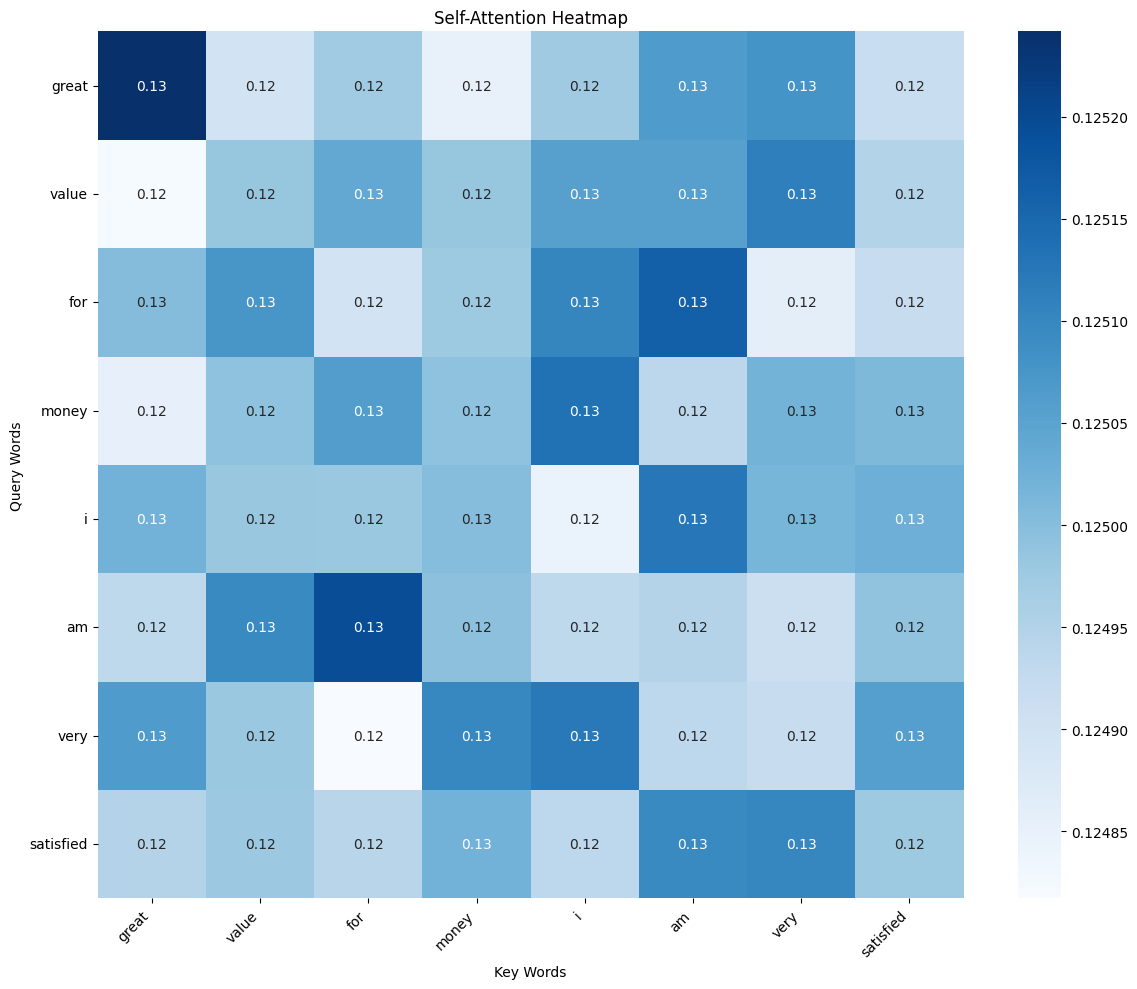

In [22]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    attention_np,
    xticklabels=tokens,
    yticklabels=tokens,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.title("Self-Attention Heatmap")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Find the word receiving the highest attention for each query word

print("Highest attention for each word:\n")

for i, query_word in enumerate(tokens):

    # Get attention values for this word
    attention_row = attention_np[i]

    # Find highest attention
    max_index = np.argmax(attention_row)

    key_word = tokens[max_index]
    max_value = attention_row[max_index]

    print(
        f"{query_word:15s} -> "
        f"{key_word:15s} "
        f"({max_value:.4f})"
    )

Highest attention for each word:

great           -> great           (0.1252)
value           -> very            (0.1251)
for             -> am              (0.1252)
money           -> i               (0.1251)
i               -> am              (0.1251)
am              -> for             (0.1252)
very            -> i               (0.1251)
satisfied       -> very            (0.1251)


In [24]:
# Find overall maximum attention value

max_position = np.unravel_index(
    np.argmax(attention_np),
    attention_np.shape
)

query_index = max_position[0]
key_index = max_position[1]

query_word = tokens[query_index]
key_word = tokens[key_index]

max_attention = attention_np[
    query_index,
    key_index
]

print("Highest Attention:")
print("------------------")
print("Query word:", query_word)
print("Key word:", key_word)
print("Attention value:", max_attention)

Highest Attention:
------------------
Query word: great
Key word: great
Attention value: 0.12524183


In [25]:
# Create a list of all attention connections

attention_connections = []

for i, query_word in enumerate(tokens):
    for j, key_word in enumerate(tokens):

        attention_connections.append({
            "Query": query_word,
            "Key": key_word,
            "Attention": attention_np[i, j]
        })

# Convert to DataFrame
attention_df = pd.DataFrame(attention_connections)

# Sort by attention
attention_df = attention_df.sort_values(
    by="Attention",
    ascending=False
)

# Display top 10
print("Top 10 attention connections:")

display(
    attention_df.head(10)
)

Top 10 attention connections:


,Query,Key,Attention
0,great,great,0.125242
42,am,for,0.125194
21,for,am,0.125164
28,money,i,0.125134
37,i,am,0.125127
52,very,i,0.125124
14,value,very,0.125114
20,for,i,0.125104
62,satisfied,very,0.125102
51,very,money,0.125100


In [26]:
print("=" * 60)
print("SELF-ATTENTION ASSIGNMENT SUMMARY")
print("=" * 60)

print("\n1. Dataset")
print("Number of reviews:", len(df))

print("\n2. Vocabulary")
print("Vocabulary size:", len(word_index))

print("\n3. Selected sentence")
print(selected_sentence)

print("\n4. Number of tokens")
print(len(tokens))

print("\n5. Embedding dimension")
print(embedding_dim)

print("\n6. Q shape")
print(Q.shape)

print("\n7. K shape")
print(K.shape)

print("\n8. V shape")
print(V.shape)

print("\n9. Attention matrix shape")
print(attention_weights.shape)

print("\n10. Highest attention")
print(
    f"{query_word} -> {key_word} "
    f"({max_attention:.4f})"
)

print("\nAssignment completed successfully!")

SELF-ATTENTION ASSIGNMENT SUMMARY

1. Dataset
Number of reviews: 1000

2. Vocabulary
Vocabulary size: 88

3. Selected sentence
Great value for money, I am very satisfied!

4. Number of tokens
8

5. Embedding dimension
64

6. Q shape
(8, 64)

7. K shape
(8, 64)

8. V shape
(8, 64)

9. Attention matrix shape
(8, 8)

10. Highest attention
satisfied -> satisfied (0.1252)

Assignment completed successfully!
